In [1]:
# /home/admin/LLM/LLM/01/web/notebooks/analysis.ipynb

import sys
sys.path.insert(0, '/home/admin/LLM/LLM/01/web')

# Single imports per library
from src.visualizer import RAGVisualizer
import pandas as pd

# Initialize once
viz = RAGVisualizer()
df = viz.load_selected_experiments(viz.get_experiment_registry()['filename'].tolist())

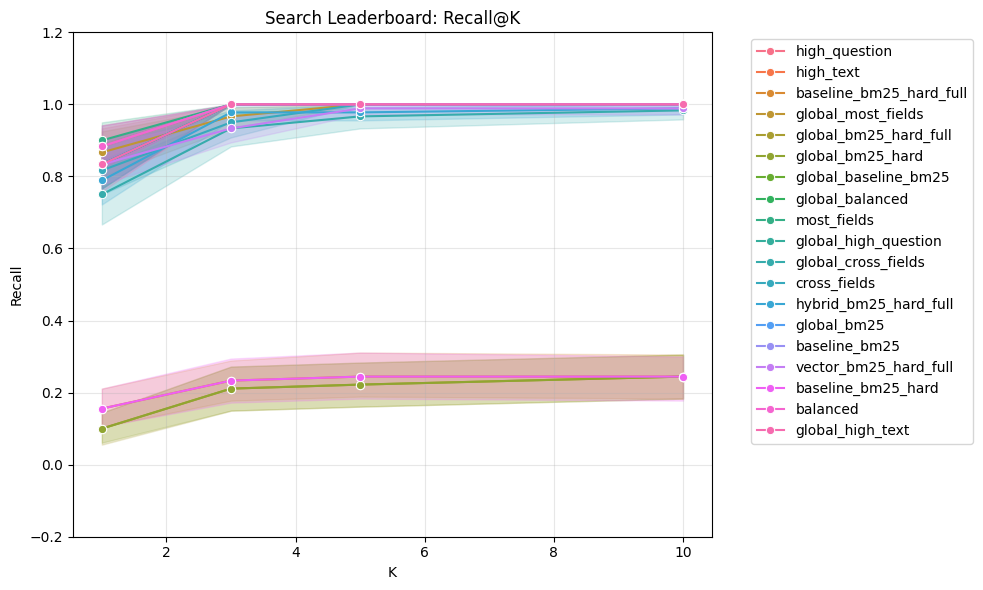

,recall@5,mrr,precision@5,hit_rate@5,unique_courses@5,entropy@5,p95_latency_ms
run_label,,,,,,,
balanced,1.0000,1.0,1.0000,1.0000,3,1.5850,3.1525
baseline_bm25,1.0000,1.0,1.0000,1.0000,3,1.5850,3.1530
baseline_bm25_hard,0.2444,1.0,0.2444,0.2444,4,1.9626,3.0100
baseline_bm25_hard_full,0.2444,1.0,0.2444,0.2444,4,1.9626,2.7800
cross_fields,1.0000,1.0,1.0000,1.0000,3,1.5850,3.4220
global_balanced,1.0000,1.0,1.0000,1.0000,3,1.5838,3.2335
global_baseline_bm25,1.0000,1.0,1.0000,1.0000,3,1.5838,3.1030
global_bm25,1.0000,1.0,1.0000,1.0000,3,1.5838,3.4615
global_bm25_hard,0.2222,1.0,0.2222,0.2222,4,1.6028,3.0300


expected_course,data-engineering-zoomcamp,machine-learning-zoomcamp,mlops-zoomcamp
run_label,,,
balanced,1.000000,1.000000,1.000000
baseline_bm25,1.000000,1.000000,1.000000
baseline_bm25_hard,0.233333,0.266667,0.233333
baseline_bm25_hard_full,0.233333,0.266667,0.233333
cross_fields,1.000000,1.000000,1.000000
global_balanced,1.000000,1.000000,1.000000
global_baseline_bm25,1.000000,1.000000,1.000000
global_bm25,1.000000,1.000000,1.000000
global_bm25_hard,0.166667,0.266667,0.233333


run_label
global_bm25_hard_full      0.577778
global_bm25_hard           0.577778
baseline_bm25_hard         0.244444
baseline_bm25_hard_full    0.244444
global_cross_fields        0.083333
global_most_fields         0.050000
global_high_text           0.050000
global_balanced            0.050000
global_baseline_bm25       0.050000
global_bm25                0.050000
global_high_question       0.050000
baseline_bm25              0.000000
balanced                   0.000000
cross_fields               0.000000
high_question              0.000000
high_text                  0.000000
hybrid_bm25_hard_full      0.000000
most_fields                0.000000
vector_bm25_hard_full      0.000000
dtype: float64

run_label
balanced                   1.000000
baseline_bm25              1.000000
cross_fields               1.000000
high_text                  1.000000
global_balanced            1.000000
global_baseline_bm25       1.000000
global_bm25                1.000000
high_question              1.000000
global_most_fields         1.000000
global_high_text           1.000000
global_high_question       1.000000
most_fields                1.000000
vector_bm25_hard_full      0.988889
hybrid_bm25_hard_full      0.977778
global_cross_fields        0.966667
baseline_bm25_hard         0.244444
baseline_bm25_hard_full    0.244444
global_bm25_hard_full      0.222222
global_bm25_hard           0.222222
Name: success, dtype: float64

k,1,3,5,10
run_label,,,,
balanced,2.530333,2.419833,2.473333,2.740333
baseline_bm25,2.522833,2.521500,2.538000,2.690500
baseline_bm25_hard,2.118556,2.317222,2.401000,2.468444
baseline_bm25_hard_full,1.966222,1.703333,1.909111,2.588333
cross_fields,2.615500,2.700667,2.703000,3.085000
global_balanced,2.534500,2.930167,2.577167,2.556667
global_baseline_bm25,2.351500,2.342000,2.497500,2.705667
global_bm25,2.290667,2.489500,2.665167,2.800167
global_bm25_hard,2.173444,2.486778,2.252778,2.384333


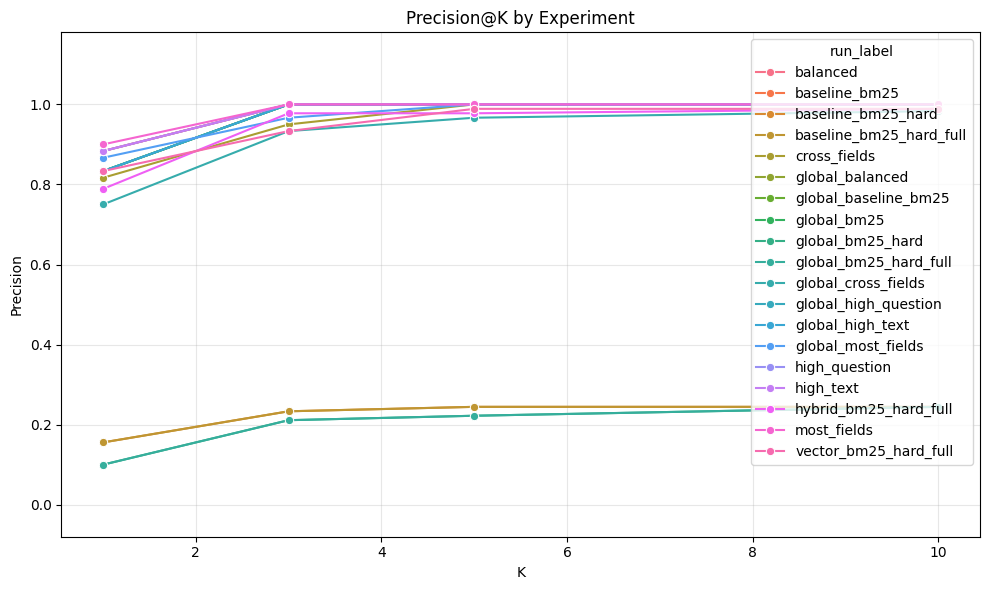

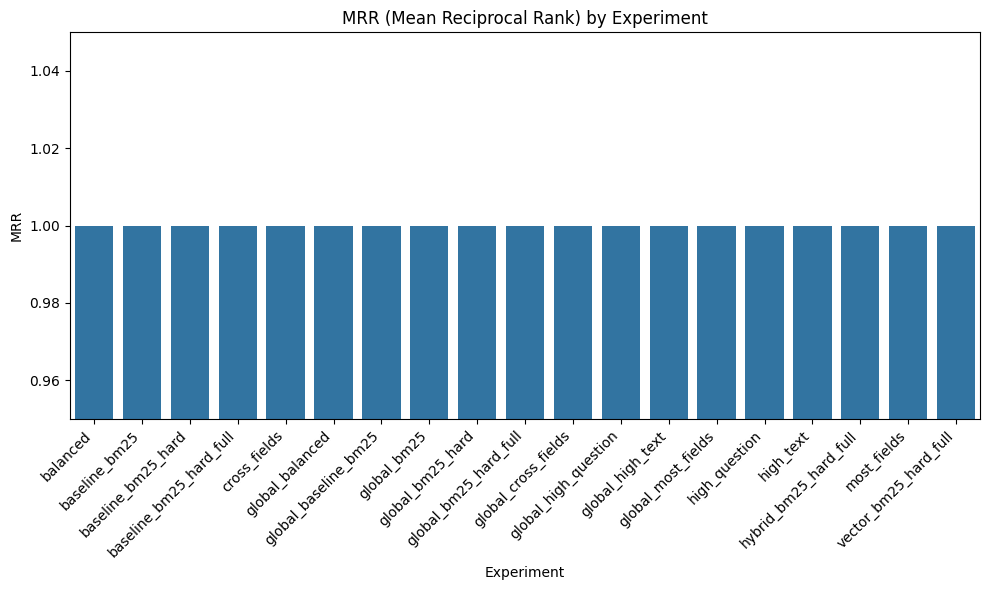

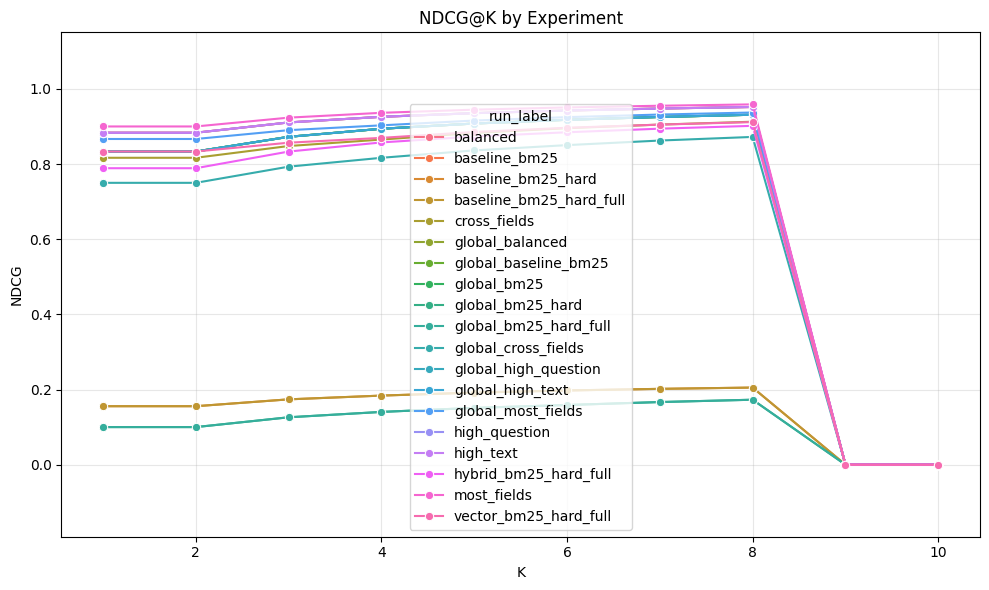

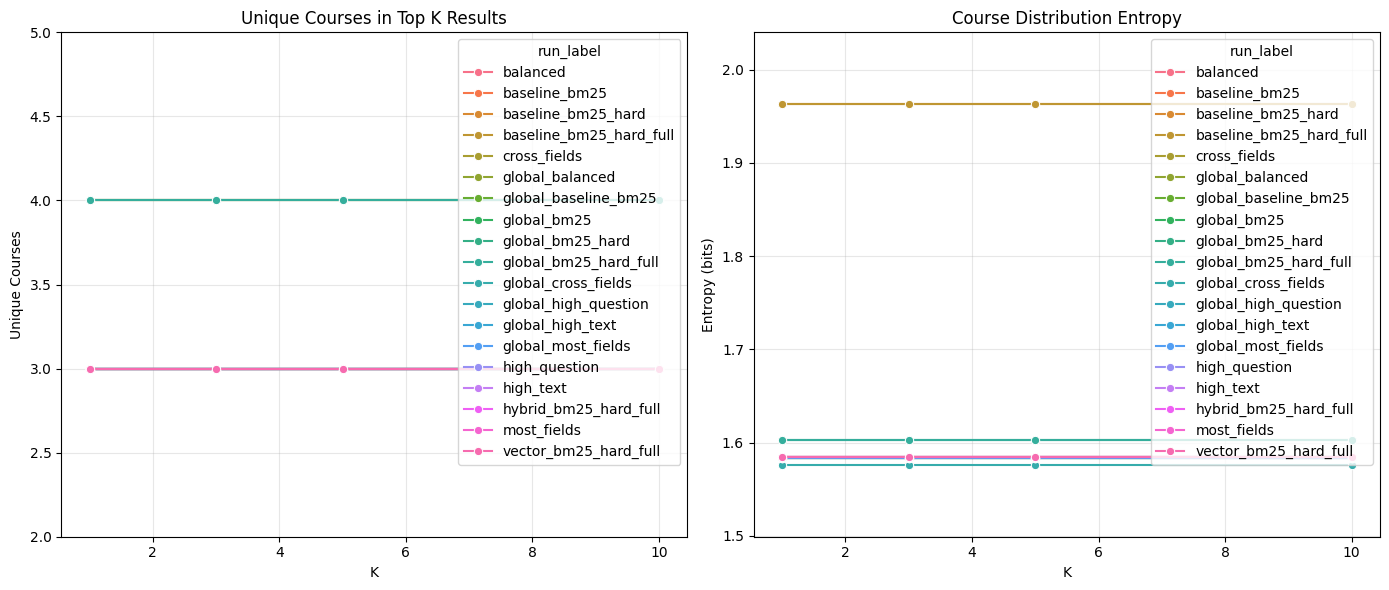

In [2]:
# 1. Leaderboard (Recall@K)
viz.plot_leaderboard(df)

# 2. Comprehensive summary
summary = viz.get_comprehensive_summary(df)
display(summary)

# 3. Recall by course at K=5
recall_by_course = df[df['k'] == 5].groupby(['run_label', 'expected_course'])['success'].mean().unstack()
display(recall_by_course)

# 4. Cross-course rate
cross_rate = (df[df['k'] == 5].groupby('run_label').apply(
    lambda g: (g['expected_course'] != g['found_course']).mean()
))
display(cross_rate.sort_values(ascending=False))

# 5. Best configs by recall@5
best = df[df['k'] == 5].groupby('run_label')['success'].mean().sort_values(ascending=False)
display(best)

# 6. Latency comparison
latency = df.groupby(['run_label', 'k'])['latency_ms'].mean().unstack()
display(latency)

# 7. Precision@K
precision = viz.compute_precision_at_k(df)
viz.plot_precision_at_k(precision)

# 8. MRR comparison
mrr = viz.compute_mrr(df)
viz.plot_mrr_comparison(mrr)

# 9. NDCG comparison
ndcg = viz.compute_ndcg(df)
viz.plot_ndcg_comparison(ndcg)

# 10. Diversity metrics
unique = viz.compute_unique_courses_in_top_k(df)
entropy = viz.compute_course_entropy(df)
viz.plot_diversity_metrics(unique, entropy)

In [3]:
import sys
sys.path.insert(0, '/home/admin/LLM/LLM/01/web')

from src.visualizer import RAGVisualizer
import pandas as pd

viz = RAGVisualizer()
registry = viz.get_experiment_registry()
filenames = registry['filename'].tolist()
df = viz.load_selected_experiments(filenames)
print("=" * 60)
print("SEARCH EVALUATION RESULTS")
print("=" * 60)

# 1. Best configs by recall@5
best = df[df['k'] == 5].groupby('run_label')['success'].mean().sort_values(ascending=False)
print("\n=== BEST CONFIGS BY RECALL@5 ===")
print(best.round(4).to_string())

# 2. Recall by course at K=5
recall_by_course = df[df['k'] == 5].groupby(['run_label', 'expected_course'])['success'].mean().unstack()
print("\n=== RECALL@5 BY COURSE ===")
print(recall_by_course.round(4).to_string())

# 3. Cross-course rate
df['is_cross'] = df['expected_course'] != df['found_course']
cross_rate = df[df['k'] == 5].groupby('run_label')['is_cross'].mean().sort_values(ascending=False)
print("\n=== CROSS-COURSE RATE (K=5) ===")
print(cross_rate.round(4).to_string())

# 4. Average latency by config
latency = df[df['k'] == 5].groupby('run_label')['latency_ms'].mean().sort_values()
print("\n=== AVG LATENCY (ms) at K=5 ===")
print(latency.round(2).to_string())

# 5. Best global config (no filter)
global_configs = [c for c in best.index if c.startswith('global_')]
global_best = best[global_configs]
print("\n=== BEST GLOBAL CONFIGS (No course filter) ===")
print(global_best.round(4).to_string())

# 6. Raw data sample for verification
print("\n=== SAMPLE RESULTS (First 5 DE queries) ===")
de_sample = df[(df['k'] == 5) & (df['expected_course'] == 'data-engineering-zoomcamp')].head(5)
print(de_sample[['query', 'found_course', 'success', 'score']].to_string())

# 7. Summary table
print("\n=== COMPREHENSIVE SUMMARY ===")
summary = viz.get_comprehensive_summary(df)
print(summary.round(4).to_string())

SEARCH EVALUATION RESULTS

=== BEST CONFIGS BY RECALL@5 ===
run_label
balanced                   1.0000
baseline_bm25              1.0000
cross_fields               1.0000
high_text                  1.0000
global_balanced            1.0000
global_baseline_bm25       1.0000
global_bm25                1.0000
high_question              1.0000
global_most_fields         1.0000
global_high_text           1.0000
global_high_question       1.0000
most_fields                1.0000
vector_bm25_hard_full      0.9889
hybrid_bm25_hard_full      0.9778
global_cross_fields        0.9667
baseline_bm25_hard         0.2444
baseline_bm25_hard_full    0.2444
global_bm25_hard_full      0.2222
global_bm25_hard           0.2222

=== RECALL@5 BY COURSE ===
expected_course          data-engineering-zoomcamp  machine-learning-zoomcamp  mlops-zoomcamp
run_label                                                                                    
balanced                                    1.0000                  

In [4]:
from notebooks.ab_test import run_ab_test

df = run_ab_test("baseline_bm25", "global_cross_fields", num_queries=10)

/home/admin/LLM/LLM/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-05-06 14:06:58,808 [INFO] - Loaded LlamaIndex LLM: nvidia_nim/meta/llama-3.1-8b-instruct
2026-05-06 14:06:58,814 [INFO] - Initialized evaluators with LLM: nvidia_nim/meta/llama-3.1-8b-instruct


2026-05-06 14:06:58,819 [INFO] - GET http://localhost:9200/ [status:200 request:0.003s]
2026-05-06 14:06:58,821 [INFO] - HEAD http://localhost:9200/ [status:200 request:0.001s]
2026-05-06 14:06:58,825 [INFO] - GET http://localhost:9200/ [status:200 request:0.002s]
2026-05-06 14:06:58,826 [INFO] - HEAD http://localhost:9200/ [status:200 request:0.001s]
2026-05-06 14:06:58,831 [INFO] - POST http://localhost:9200/course-questions/_search [status:200 request:0.003s]


2026-05-06 14:06:58,832 [INFO] - Function 'search_faq' executed in 0.0050s


2026-05-06 14:06:58,836 [INFO] - POST http://localhost:9200/course-questions/_search [status:200 request:0.003s]


...

2026-05-06 14:06:58,904 [INFO] - Function 'search_faq' executed in 0.0057s


2026-05-06 14:06:58,908 [INFO] - POST http://localhost:9200/course-questions/_search [status:200 request:0.003s]


2026-05-06 14:06:58,910 [INFO] - Function 'search_faq' executed in 0.0046s


2026-05-06 14:06:58,914 [INFO] - POST http://localhost:9200/course-questions/_search [status:200 request:0.003s]


2026-05-06 14:06:58,915 [INFO] - Function 'search_faq' executed in 0.0042s
A/B TEST: baseline_bm25 vs global_cross_fields

Q: When will the course start?
Expected: data-engineering-zoomcamp
[A] baseline_bm25: data-engineering-zoomcamp (score: 414.23)
    When will the course start?...
[B] global_cross_fields: data-engineering-zoomcamp (score: 10.64)
    When will the course start?...
----------------------------------------

Q: What are the prerequisites for this course?
Expected: data-engineering-zoomcamp
[A] baseline_bm25: data-engineering-zoomcamp (score: 533.12)
    What are the prerequisites for this course?...
[B] global_cross_fields: data-engineering-zoomcamp (score: 13.33)
    What are the prerequisites for this course?...
----------------------------------------

Q: Can I still join the course after the start date?
Expected: data-engineering-zoomcamp
[A] baseline_bm25: data-engineering-zoomcamp (score: 719.0)
    Can I still join the course after the start date?...
[B] global_

In [5]:
from src.experiment_pipeline import compare_configs

results, summary = compare_configs("baseline_bm25", "global_cross_fields", num_queries=20)
print(f"Winner: {summary['winner']}")
print(f"Config A wins: {summary['config_a_wins']}")
print(f"Config B wins: {summary['config_b_wins']}")
print(f"Ties: {summary['ties']}")

2026-05-06 14:06:59,008 [INFO] - Loaded LlamaIndex LLM: nvidia_nim/meta/llama-3.1-8b-instruct
2026-05-06 14:06:59,010 [INFO] - Initialized evaluators with LLM: nvidia_nim/meta/llama-3.1-8b-instruct


2026-05-06 14:06:59,015 [INFO] - GET http://localhost:9200/ [status:200 request:0.004s]
2026-05-06 14:06:59,017 [INFO] - HEAD http://localhost:9200/ [status:200 request:0.002s]
2026-05-06 14:06:59,022 [INFO] - GET http://localhost:9200/ [status:200 request:0.004s]
2026-05-06 14:06:59,025 [INFO] - HEAD http://localhost:9200/ [status:200 request:0.002s]
2026-05-06 14:06:59,031 [INFO] - POST http://localhost:9200/course-questions/_search [status:200 request:0.004s]


2026-05-06 14:06:59,032 [INFO] - Function 'search_faq' executed in 0.0055s


2026-05-06 14:06:59,035 [INFO] - POST http://localhost:9200/course-questions/_search [status:200 request:0.003s]


2026-05-06 14:06:59,037 [INFO] - Function 'search_faq' executed in 0.0043s


...

2026-05-06 14:06:59,239 [INFO] - Function 'search_faq' executed in 0.0042s


2026-05-06 14:06:59,243 [INFO] - POST http://localhost:9200/course-questions/_search [status:200 request:0.003s]


2026-05-06 14:06:59,243 [INFO] - Function 'search_faq' executed in 0.0037s


2026-05-06 14:06:59,247 [INFO] - POST http://localhost:9200/course-questions/_search [status:200 request:0.003s]


2026-05-06 14:06:59,248 [INFO] - Function 'search_faq' executed in 0.0036s
Results saved to experiments/ab_results/ab_test__baseline_bm25_vs_global_cross_fields__2026-05-06.json

🏆 WINNER: baseline_bm25
   baseline_bm25: 18 wins
   global_cross_fields: 0 wins
   Ties: 0
Winner: baseline_bm25
Config A wins: 18
Config B wins: 0
Ties: 0



📊 RETRIEVAL VS ANSWER QUALITY GAP
                         Recall %  Faithful %  Relevant %  Gap (Recall - Relevant)
run_label                                                                         
balanced                   100.00       27.50       27.50                    72.50
baseline_bm25              100.00       27.50       27.50                    72.50
baseline_bm25_hard          24.44       13.33       13.89                    10.55
baseline_bm25_hard_full     24.44       13.33       13.89                    10.55
cross_fields               100.00       26.67       26.67                    73.33
global_balanced            100.00       25.83       25.83                    74.17
global_baseline_bm25       100.00       25.83       25.83                    74.17
global_bm25                100.00       25.83       25.83                    74.17
global_bm25_hard            22.22       12.22       12.78                     9.44
global_bm25_hard_full       22.22       12.22       

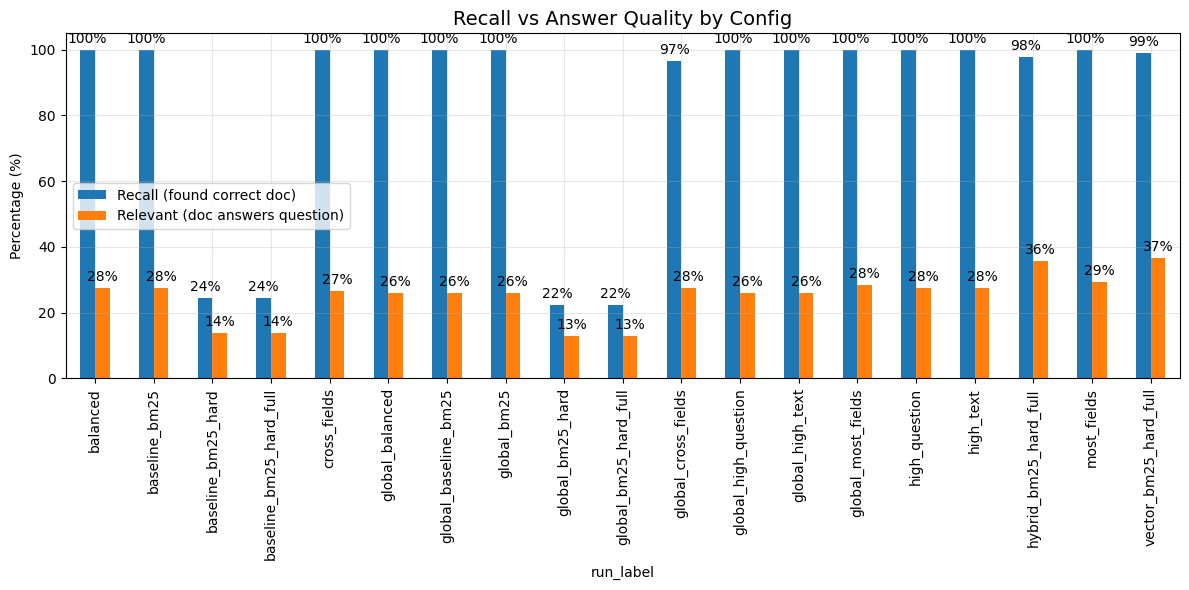

,Recall %,Faithful %,Relevant %,Gap (Recall - Relevant)
run_label,,,,
balanced,100.00,27.50,27.50,72.50
baseline_bm25,100.00,27.50,27.50,72.50
baseline_bm25_hard,24.44,13.33,13.89,10.55
baseline_bm25_hard_full,24.44,13.33,13.89,10.55
cross_fields,100.00,26.67,26.67,73.33
global_balanced,100.00,25.83,25.83,74.17
global_baseline_bm25,100.00,25.83,25.83,74.17
global_bm25,100.00,25.83,25.83,74.17
global_bm25_hard,22.22,12.22,12.78,9.44


In [6]:
from src.visualizer import RAGVisualizer

viz = RAGVisualizer()
registry = viz.get_experiment_registry()
filenames = registry['filename'].tolist()
df = viz.load_selected_experiments(filenames)

# Plot quality gap (if quality metrics exist)
viz.plot_quality_gap(df)